# 05 — Single Model Baseline: Optimized Random Forest

**Tujuan:** Membangun baseline **terbaik** dengan satu model (Random Forest) sebagai pembanding terhadap multi-view stacking ensemble.

**Pipeline:**
```
Raw CSV
  → Decode categoricals
  → Advanced Feature Engineering (40+ engineered features)
  → Train-Test Split (stratified, sebelum encoding)
  → OHE nominal + Ordinal score untuk parent edu/occ
  → PowerTransformer (Yeo-Johnson) untuk skewed numerics
  → RobustScaler (robust terhadap outlier)
  → Optuna: 120 trials — n_estimators, depth, leaves, features, criterion, class_weight
  → Full Evaluation (classification report, ROC AUC, feature importance)
  → Save baseline bundle
```

---
## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.preprocessing import (
    PowerTransformer, RobustScaler, OneHotEncoder
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.base import clone
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
class_names  = ['Graduate', 'Enrolled', 'Dropout']
PALETTE      = {'Graduate': '#2ecc71', 'Enrolled': '#3498db', 'Dropout': '#e74c3c'}

print("Setup done.")

Setup done.


---
## 1. Load & Decode Raw Data

In [2]:
df = pd.read_csv('../data/data.csv', delimiter=';')

# Fix tab in column name
df.rename(columns={'Daytime/evening attendance\t': 'Attendance'}, inplace=True)

print(f"Raw shape: {df.shape}")
print(f"Columns  : {list(df.columns)}")

Raw shape: (4424, 37)
Columns  : ['Marital status', 'Application mode', 'Application order', 'Course', 'Attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Targe

In [3]:
# ── Decode categorical columns ────────────────────────────────────────────────
marital_map = {1:'Single', 2:'Married', 3:'Widower', 4:'Divorced',
               5:'Facto union', 6:'Legally separated'}

app_mode_map = {
    1:'General 1st phase', 2:'Ordinance 612/93', 5:'Special contingent Azores',
    7:'Other higher courses', 10:'Ordinance 854-B/99', 15:'International bachelor',
    16:'Special contingent Madeira', 17:'General 2nd phase', 18:'General 3rd phase',
    26:'Ordinance 533-A/99 b2', 27:'Ordinance 533-A/99 b3', 39:'Over 23 years old',
    42:'Transfer', 43:'Change of course', 44:'Tech specialization diploma',
    51:'Change institution/course', 53:'Short cycle diploma',
    57:'Change institution/course Intl'
}

course_map = {
    33:'Biofuel Tech', 171:'Animation Multimedia', 8014:'Social Service Eve',
    9003:'Agronomy', 9070:'Communication Design', 9085:'Vet Nursing',
    9119:'Informatics Eng', 9130:'Equinculture', 9147:'Management',
    9238:'Social Service', 9254:'Tourism', 9500:'Nursing', 9556:'Oral Hygiene',
    9670:'Advertising Marketing', 9773:'Journalism', 9853:'Basic Education',
    9991:'Management Eve'
}

prev_qual_map = {
    1:'Secondary', 2:'Higher Bachelor', 3:'Higher Degree', 4:'Higher Masters',
    5:'Higher Doctorate', 6:'Freq Higher Ed', 9:'12th Not Completed',
    10:'11th Not Completed', 12:'Other 11th', 14:'10th Year',
    15:'10th Not Completed', 19:'Basic 3rd Cycle', 38:'Basic 2nd Cycle',
    39:'Tech Specialization', 40:'Higher Degree 1st', 42:'Prof Higher Tech',
    43:'Higher Masters 2nd'
}

nat_map = {
    1:'Portuguese', 2:'German', 6:'Spanish', 11:'Italian', 13:'Dutch',
    14:'English', 17:'Lithuanian', 21:'Angolan', 22:'Cape Verdean', 24:'Guinean',
    25:'Mozambican', 26:'Santomean', 32:'Turkish', 41:'Brazilian', 62:'Romanian',
    100:'Moldovan', 101:'Mexican', 103:'Ukrainian', 105:'Russian', 108:'Cuban',
    109:'Colombian'
}

parent_qual_map = {
    1:'Secondary 12th', 2:'Higher Bachelor', 3:'Higher Degree', 4:'Higher Masters',
    5:'Higher Doctorate', 6:'Freq Higher Ed', 9:'12th Not Completed',
    10:'11th Not Completed', 11:'7th Old', 12:'Other 11th', 13:'2nd Comp High',
    14:'10th Year', 18:'General Commerce', 19:'Basic 3rd Cycle', 20:'Comp High',
    22:'Tech Professional', 25:'Comp High Not Concluded', 26:'7th Year',
    27:'2nd Cycle General', 29:'9th Not Completed', 30:'8th Year',
    31:'Admin Commerce', 33:'Supp Accounting', 34:'Unknown',
    35:'Cannot Read Write', 36:'Can Read No 4th', 37:'Basic 1st Cycle',
    38:'Basic 2nd Cycle', 39:'Tech Specialization', 40:'Higher Degree 1st',
    41:'Specialized Higher', 42:'Prof Higher Tech', 43:'Higher Masters 2nd',
    44:'Higher Doctorate 3rd'
}

occ_map = {
    0:'Student', 1:'Managers', 2:'Specialists', 3:'Int Technicians',
    4:'Administrative', 5:'Personal Services', 6:'Skilled Agricultural',
    7:'Skilled Industry', 8:'Machine Operators', 9:'Unskilled Workers',
    10:'Armed Forces', 90:'Other', 99:'Blank', 101:'AF Officers',
    102:'AF Sergeants', 103:'Other AF', 112:'Admin Directors',
    114:'Hotel Directors', 121:'Science Eng Specialists', 122:'Health Professionals',
    123:'Teachers', 124:'Finance Specialists', 125:'ICT Specialists',
    131:'Sci Eng Technicians', 132:'Health Technicians', 134:'Legal Social Technicians',
    135:'ICT Technicians', 141:'Office Secretaries', 143:'Accounting Operators',
    144:'Other Admin', 151:'Personal Service Workers', 152:'Sellers',
    153:'Personal Care', 154:'Protection Security', 161:'Skilled Farmers',
    163:'Subsistence Farmers', 171:'Skilled Construction', 172:'Metallurgy',
    173:'Printing Precision', 174:'Electricity Electronics',
    175:'Food Wood Clothing', 181:'Fixed Plant Operators', 182:'Assembly Workers',
    183:'Vehicle Drivers', 191:'Cleaning Workers', 192:'Unskilled Agricultural',
    193:'Unskilled Extractive', 194:'Meal Preparation', 195:'Street Vendors'
}

df['Marital status']         = df['Marital status'].map(marital_map)
df['Application mode']       = df['Application mode'].map(app_mode_map)
df['Course']                 = df['Course'].map(course_map)
df['Previous qualification'] = df['Previous qualification'].map(prev_qual_map)
df['Nacionality']            = df['Nacionality'].map(nat_map)
df["Mother's qualification"] = df["Mother's qualification"].map(parent_qual_map)
df["Father's qualification"] = df["Father's qualification"].map(parent_qual_map)
df["Mother's occupation"]    = df["Mother's occupation"].map(occ_map)
df["Father's occupation"]    = df["Father's occupation"].map(occ_map)

target_map = {'Graduate': 0, 'Enrolled': 1, 'Dropout': 2}
df['Target_enc'] = df['Target'].map(target_map)

print(f"Decoded shape: {df.shape}")
print("\nClass distribution:")
for k, v in target_map.items():
    n = (df['Target_enc'] == v).sum()
    print(f"  {v} → {k}: {n} ({n/len(df)*100:.1f}%)")

Decoded shape: (4424, 38)

Class distribution:
  0 → Graduate: 2209 (49.9%)
  1 → Enrolled: 794 (17.9%)
  2 → Dropout: 1421 (32.1%)


---
## 2. Advanced Feature Engineering

**40+ engineered features** across 6 domains:
1. Academic Performance Ratios & Trajectories
2. Academic Failure & Ghost Student Signals
3. Academic Efficiency Composites
4. Financial Stress Indicators
5. Demographic & Background Signals
6. Macro-Economic Pressure Indices
7. Interaction Terms & Cross-Domain Features
8. Ordinal Education/Occupation Scoring

In [4]:
# ── Aliases for readability ───────────────────────────────────────────────────
S1e = df['Curricular units 1st sem (enrolled)']
S1a = df['Curricular units 1st sem (approved)']
S1g = df['Curricular units 1st sem (grade)']
S1v = df['Curricular units 1st sem (evaluations)']
S1c = df['Curricular units 1st sem (credited)']
S1w = df['Curricular units 1st sem (without evaluations)']
S2e = df['Curricular units 2nd sem (enrolled)']
S2a = df['Curricular units 2nd sem (approved)']
S2g = df['Curricular units 2nd sem (grade)']
S2v = df['Curricular units 2nd sem (evaluations)']
S2c = df['Curricular units 2nd sem (credited)']
S2w = df['Curricular units 2nd sem (without evaluations)']

EPS = 1e-6  # avoid division by zero

# ─── DOMAIN 1: Academic Performance Ratios ────────────────────────────────────
df['Approval_rate_1st']     = S1a / (S1e + EPS)
df['Approval_rate_2nd']     = S2a / (S2e + EPS)
df['Approval_rate_overall'] = (S1a + S2a) / (S1e + S2e + EPS)
df['Grade_avg']             = (S1g + S2g) / 2
df['Grade_improvement']     = S2g - S1g      # positive=improving, negative=declining
df['Grade_consistency']     = df[[
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]].std(axis=1).fillna(0)
df['Total_approved']        = S1a + S2a
df['Total_enrolled']        = S1e + S2e
df['Total_credited']        = S1c + S2c

# Grade relative to admission (over/underperforming)
df['Admission_grade_norm']  = df['Admission grade'] / 200 * 20  # scale 0-20
df['Prev_qual_grade_norm']  = df['Previous qualification (grade)'] / 200 * 20
df['Grade_vs_admission']    = df['Grade_avg'] - df['Admission_grade_norm']
df['Grade_vs_prev_qual']    = df['Grade_avg'] - df['Prev_qual_grade_norm']

# ─── DOMAIN 2: Failure & Ghost Student Signals ───────────────────────────────
df['Fail_count_1st']        = (S1e - S1a).clip(lower=0)
df['Fail_count_2nd']        = (S2e - S2a).clip(lower=0)
df['Total_fails']           = df['Fail_count_1st'] + df['Fail_count_2nd']
df['Fail_rate_1st']         = df['Fail_count_1st'] / (S1e + EPS)
df['Fail_rate_2nd']         = df['Fail_count_2nd'] / (S2e + EPS)
df['Zero_eval_1st']         = (S1v == 0).astype(int)
df['Zero_eval_2nd']         = (S2v == 0).astype(int)
df['Zero_eval_both']        = (df['Zero_eval_1st'] & df['Zero_eval_2nd']).astype(int)
df['Has_without_eval_1st']  = (S1w > 0).astype(int)
df['Has_without_eval_2nd']  = (S2w > 0).astype(int)
df['Without_eval_ratio_1st']= S1w / (S1e + EPS)
df['Without_eval_ratio_2nd']= S2w / (S2e + EPS)
df['Enrollment_decline']    = (S2e < S1e).astype(int)  # dropout signal: reducing load

# ─── DOMAIN 3: Academic Efficiency Composites ────────────────────────────────
df['Eval_intensity_1st']    = S1v / (S1e + EPS)
df['Eval_intensity_2nd']    = S2v / (S2e + EPS)
df['Efficiency_1st']        = S1g * df['Approval_rate_1st']   # grade × approval
df['Efficiency_2nd']        = S2g * df['Approval_rate_2nd']
df['Efficiency_overall']    = df['Grade_avg'] * df['Approval_rate_overall']
df['Approval_momentum']     = df['Approval_rate_2nd'] - df['Approval_rate_1st']  # improving/declining
df['Credit_utilization']    = df['Total_credited'] / (df['Total_enrolled'] + EPS)

# ─── DOMAIN 4: Financial Stress ──────────────────────────────────────────────
df['Financial_risk_score']  = (
    (df['Tuition fees up to date'] == 0).astype(int) * 2 +  # most critical
    df['Debtor'] +
    (df['Scholarship holder'] == 0).astype(int)
)  # range 0-4
df['Tuition_no_scholarship'] = (
    (df['Tuition fees up to date'] == 0) & (df['Scholarship holder'] == 0)
).astype(int)
df['Debtor_no_scholarship']  = (
    (df['Debtor'] == 1) & (df['Scholarship holder'] == 0)
).astype(int)

# ─── DOMAIN 5: Demographic Signals ───────────────────────────────────────────
df['Is_older_student']      = (df['Age at enrollment'] >= 25).astype(int)
df['Is_very_old']           = (df['Age at enrollment'] >= 35).astype(int)
df['Is_evening']            = (df['Attendance'] == 0).astype(int)
df['Is_international_nat']  = (df['Nacionality'] != 'Portuguese').astype(int)
df['Age_squared']           = df['Age at enrollment'] ** 2  # non-linear age effect
df['Is_displaced']          = df['Displaced'].astype(int)

# ─── DOMAIN 6: Macro-Economic Pressure ───────────────────────────────────────
df['GDP_unemployment_ratio'] = df['GDP'] / (df['Unemployment rate'] + EPS)
df['Economic_pressure']      = df['Unemployment rate'] - df['GDP']  # high = worse economy
df['Inflation_x_unemp']     = df['Inflation rate'] * df['Unemployment rate']

# ─── DOMAIN 7: Cross-Domain Interaction Terms ─────────────────────────────────
df['Academic_x_financial']   = df['Efficiency_overall'] * (4 - df['Financial_risk_score'])  # protective
df['Grade_x_financial_risk'] = df['Grade_avg'] * df['Financial_risk_score']                 # stress = lower grade?
df['Age_x_financial_risk']   = df['Age at enrollment'] * df['Financial_risk_score']
df['Age_x_approval_rate']    = df['Age at enrollment'] * df['Approval_rate_overall']
df['Fail_x_financial']       = df['Total_fails'] * df['Financial_risk_score']
df['Approval_x_tuition']     = df['Approval_rate_overall'] * df['Tuition fees up to date']

# ─── DOMAIN 8: Education Level Ordinal Scoring ───────────────────────────────
# Convert parent education to ordered numeric score (0 = illiterate, 10 = PhD)
edu_score_map = {
    'Cannot Read Write': 0, 'Can Read No 4th': 0.5, 'Basic 1st Cycle': 1,
    'Basic 2nd Cycle': 2, 'Basic 3rd Cycle': 3, '7th Old': 2.5, '8th Year': 2.5,
    '9th Not Completed': 2.5, '10th Year': 3, '10th Not Completed': 2.5,
    '11th Not Completed': 3.5, 'Other 11th': 3.5, '12th Not Completed': 4,
    '2nd Comp High': 3.5, '2nd Cycle General': 3.5, '7th Year': 2,
    'General Commerce': 4, 'Comp High Not Concluded': 4, 'Comp High': 4,
    'Admin Commerce': 4, 'Supp Accounting': 4, 'Tech Professional': 4.5,
    'Tech Specialization': 5, 'Freq Higher Ed': 5, 'Secondary 12th': 4,
    'Specialized Higher': 6, 'Prof Higher Tech': 5.5, 'Higher Degree 1st': 6,
    'Higher Bachelor': 6, 'Higher Degree': 7, 'Higher Masters': 8,
    'Higher Masters 2nd': 8, 'Higher Doctorate': 9, 'Higher Doctorate 3rd': 9,
    'Unknown': 3
}
df['Mother_edu_score'] = df["Mother's qualification"].map(edu_score_map).fillna(3)
df['Father_edu_score'] = df["Father's qualification"].map(edu_score_map).fillna(3)
df['Parent_edu_avg']   = (df['Mother_edu_score'] + df['Father_edu_score']) / 2
df['Parent_edu_max']   = df[['Mother_edu_score', 'Father_edu_score']].max(axis=1)

# Occupation prestige score (0=lowest, 5=highest)
occ_prestige_map = {
    'Managers': 5, 'Specialists': 5, 'Health Professionals': 5, 'Teachers': 5,
    'Finance Specialists': 5, 'ICT Specialists': 5, 'Science Eng Specialists': 5,
    'AF Officers': 4, 'Admin Directors': 4, 'Hotel Directors': 4,
    'Int Technicians': 4, 'Health Technicians': 4, 'Sci Eng Technicians': 4,
    'Legal Social Technicians': 4, 'ICT Technicians': 4,
    'Administrative': 3, 'Office Secretaries': 3, 'Accounting Operators': 3,
    'Personal Services': 2, 'Sellers': 2, 'Personal Care': 2,
    'Protection Security': 2, 'Skilled Agricultural': 2, 'Skilled Industry': 2,
    'Skilled Construction': 2, 'Skilled Farmers': 2, 'Metallurgy': 2,
    'Machine Operators': 2, 'Assembly Workers': 2, 'Vehicle Drivers': 2,
    'Fixed Plant Operators': 2, 'Electricity Electronics': 2,
    'Food Wood Clothing': 2, 'Printing Precision': 2,
    'Unskilled Workers': 1, 'Cleaning Workers': 1, 'Unskilled Agricultural': 1,
    'Unskilled Extractive': 1, 'Meal Preparation': 1, 'Street Vendors': 1,
    'Subsistence Farmers': 1, 'Student': 2, 'Other': 2, 'Blank': 2,
    'AF Sergeants': 3, 'Other AF': 3, 'Armed Forces': 3
}
df['Mother_occ_prestige'] = df["Mother's occupation"].map(occ_prestige_map).fillna(2)
df['Father_occ_prestige'] = df["Father's occupation"].map(occ_prestige_map).fillna(2)
df['Parent_occ_max']      = df[['Mother_occ_prestige', 'Father_occ_prestige']].max(axis=1)
df['Parent_occ_avg']      = (df['Mother_occ_prestige'] + df['Father_occ_prestige']) / 2

# Composite SES (Socioeconomic Status)
df['SES_score']           = (df['Parent_edu_avg'] / 9 + df['Parent_occ_avg'] / 5) / 2
df['SES_x_financial_risk']= df['SES_score'] * df['Financial_risk_score']

engineered_features = [
    # Domain 1
    'Approval_rate_1st', 'Approval_rate_2nd', 'Approval_rate_overall',
    'Grade_avg', 'Grade_improvement', 'Grade_consistency',
    'Total_approved', 'Total_enrolled', 'Total_credited',
    'Admission_grade_norm', 'Prev_qual_grade_norm',
    'Grade_vs_admission', 'Grade_vs_prev_qual',
    # Domain 2
    'Fail_count_1st', 'Fail_count_2nd', 'Total_fails',
    'Fail_rate_1st', 'Fail_rate_2nd',
    'Zero_eval_1st', 'Zero_eval_2nd', 'Zero_eval_both',
    'Has_without_eval_1st', 'Has_without_eval_2nd',
    'Without_eval_ratio_1st', 'Without_eval_ratio_2nd', 'Enrollment_decline',
    # Domain 3
    'Eval_intensity_1st', 'Eval_intensity_2nd',
    'Efficiency_1st', 'Efficiency_2nd', 'Efficiency_overall',
    'Approval_momentum', 'Credit_utilization',
    # Domain 4
    'Financial_risk_score', 'Tuition_no_scholarship', 'Debtor_no_scholarship',
    # Domain 5
    'Is_older_student', 'Is_very_old', 'Is_evening',
    'Is_international_nat', 'Age_squared', 'Is_displaced',
    # Domain 6
    'GDP_unemployment_ratio', 'Economic_pressure', 'Inflation_x_unemp',
    # Domain 7
    'Academic_x_financial', 'Grade_x_financial_risk', 'Age_x_financial_risk',
    'Age_x_approval_rate', 'Fail_x_financial', 'Approval_x_tuition',
    # Domain 8
    'Mother_edu_score', 'Father_edu_score', 'Parent_edu_avg', 'Parent_edu_max',
    'Mother_occ_prestige', 'Father_occ_prestige', 'Parent_occ_avg', 'Parent_occ_max',
    'SES_score', 'SES_x_financial_risk'
]

print(f"Engineered features: {len(engineered_features)}")
print(f"Total df shape: {df.shape}")

Engineered features: 61
Total df shape: (4424, 99)


In [5]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
   

---
## 3. Feature Selection & Train-Test Split
> Split dilakukan **sebelum** encoding/scaling — mencegah leakage

In [6]:
# ── Define all feature groups ─────────────────────────────────────────────────
numeric_raw = [
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Age at enrollment', 'Application order',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

binary_features = [
    'Gender', 'Attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'International'
]

# High-cardinality nominals → OHE (grouped rare categories)
nominal_ohe = [
    'Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality'
]

# Low-cardinality nominal → already ordinal-scored above; skip raw OHE
# (Mother's/Father's qual & occupation → edu_score & occ_prestige used instead)

all_numeric_eng  = numeric_raw + engineered_features
all_features_raw = numeric_raw + binary_features + engineered_features + nominal_ohe

# Subset df
X_raw = df[all_features_raw].copy()
y     = df['Target_enc'].values

# Stratified split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"\nClass distribution (train):")
for i, n in enumerate(class_names):
    cnt = (y_train == i).sum()
    print(f"  {n}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Train: (3539, 93) | Test: (885, 93)

Class distribution (train):
  Graduate: 1767 (49.9%)
  Enrolled: 635 (17.9%)
  Dropout: 1137 (32.1%)


---
## 4. One-Hot Encoding untuk Nominal Kategoricals
Rare categories (< 1% train) digabung ke `'Other'` sebelum OHE untuk menghindari sparse dummy columns.

In [7]:
def group_rare_categories(series_train, series_test, threshold=0.01):
    """
    Group categories with frequency < threshold in train → 'Other'.
    Apply same grouping to test (fit on train only).
    """
    freq = series_train.value_counts(normalize=True)
    rare = freq[freq < threshold].index.tolist()
    s_tr = series_train.apply(lambda x: 'Other' if x in rare else x).fillna('Unknown')
    s_te = series_test.apply(lambda x: 'Other' if x in rare else x).fillna('Unknown')
    # Test may have categories not in train → 'Other'
    known = set(s_tr.unique())
    s_te  = s_te.apply(lambda x: x if x in known else 'Other')
    return s_tr, s_te

# Apply rare grouping per nominal column
X_tr_nom = {}
X_te_nom = {}
for col in nominal_ohe:
    tr_g, te_g = group_rare_categories(
        X_train_raw[col], X_test_raw[col], threshold=0.01
    )
    X_tr_nom[col] = tr_g
    X_te_nom[col] = te_g
    print(f"  {col}: {X_train_raw[col].nunique()} → {tr_g.nunique()} cats after grouping")

X_tr_nom_df = pd.DataFrame(X_tr_nom)
X_te_nom_df = pd.DataFrame(X_te_nom)

# OHE (fit on train only)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_tr_nom_df)

ohe_cols_tr = ohe.transform(X_tr_nom_df)
ohe_cols_te = ohe.transform(X_te_nom_df)
ohe_col_names = ohe.get_feature_names_out(nominal_ohe)

print(f"\nOHE generated {len(ohe_col_names)} dummy columns")
print(f"Sample OHE columns: {list(ohe_col_names[:35])}")

  Marital status: 6 → 4 cats after grouping
  Application mode: 18 → 10 cats after grouping
  Course: 17 → 17 cats after grouping
  Previous qualification: 17 → 5 cats after grouping
  Nacionality: 20 → 2 cats after grouping

OHE generated 33 dummy columns
Sample OHE columns: ['Marital status_Married', 'Marital status_Other', 'Marital status_Single', 'Application mode_Change of course', 'Application mode_General 1st phase', 'Application mode_General 2nd phase', 'Application mode_General 3rd phase', 'Application mode_Other', 'Application mode_Other higher courses', 'Application mode_Over 23 years old', 'Application mode_Tech specialization diploma', 'Application mode_Transfer', 'Course_Agronomy', 'Course_Animation Multimedia', 'Course_Basic Education', 'Course_Communication Design', 'Course_Equinculture', 'Course_Informatics Eng', 'Course_Journalism', 'Course_Management', 'Course_Management Eve', 'Course_Nursing', 'Course_Oral Hygiene', 'Course_Other', 'Course_Social Service', 'Course_S

In [8]:
print(list(ohe_col_names))

['Marital status_Married', 'Marital status_Other', 'Marital status_Single', 'Application mode_Change of course', 'Application mode_General 1st phase', 'Application mode_General 2nd phase', 'Application mode_General 3rd phase', 'Application mode_Other', 'Application mode_Other higher courses', 'Application mode_Over 23 years old', 'Application mode_Tech specialization diploma', 'Application mode_Transfer', 'Course_Agronomy', 'Course_Animation Multimedia', 'Course_Basic Education', 'Course_Communication Design', 'Course_Equinculture', 'Course_Informatics Eng', 'Course_Journalism', 'Course_Management', 'Course_Management Eve', 'Course_Nursing', 'Course_Oral Hygiene', 'Course_Other', 'Course_Social Service', 'Course_Social Service Eve', 'Course_Tourism', 'Course_Vet Nursing', 'Previous qualification_Higher Degree', 'Previous qualification_Other', 'Previous qualification_Secondary', 'Previous qualification_Tech Specialization', 'Nacionality_Portuguese']


---
## 5. Transform & Scaling

**Strategy:**
- **PowerTransformer (Yeo-Johnson)** pada numeric continuous → menormalkan distribusi skewed (grade, age, counts), tidak require positive values
- **RobustScaler** setelah PowerTransform → mengurangi pengaruh outlier yang tersisa
- Binary features & OHE columns: tidak discale (sudah 0/1)
- Engineered binary flags: tidak discale

In [9]:
# Columns that go through PowerTransform + RobustScaler
# (continuous numeric: raw + continuous engineered)
continuous_numeric = numeric_raw + [
    'Approval_rate_1st', 'Approval_rate_2nd', 'Approval_rate_overall',
    'Grade_avg', 'Grade_improvement', 'Grade_consistency',
    'Total_approved', 'Total_enrolled', 'Total_credited',
    'Admission_grade_norm', 'Prev_qual_grade_norm',
    'Grade_vs_admission', 'Grade_vs_prev_qual',
    'Fail_count_1st', 'Fail_count_2nd', 'Total_fails',
    'Fail_rate_1st', 'Fail_rate_2nd',
    'Without_eval_ratio_1st', 'Without_eval_ratio_2nd',
    'Eval_intensity_1st', 'Eval_intensity_2nd',
    'Efficiency_1st', 'Efficiency_2nd', 'Efficiency_overall',
    'Approval_momentum', 'Credit_utilization',
    'Age_squared',
    'GDP_unemployment_ratio', 'Economic_pressure', 'Inflation_x_unemp',
    'Academic_x_financial', 'Grade_x_financial_risk', 'Age_x_financial_risk',
    'Age_x_approval_rate', 'Fail_x_financial', 'Approval_x_tuition',
    'Mother_edu_score', 'Father_edu_score', 'Parent_edu_avg', 'Parent_edu_max',
    'Mother_occ_prestige', 'Father_occ_prestige', 'Parent_occ_avg', 'Parent_occ_max',
    'SES_score', 'SES_x_financial_risk'
]

# Binary/flag features: no scaling needed
binary_eng = binary_features + [
    'Financial_risk_score',  # ordinal 0-4, treat as numeric but no power transform
    'Tuition_no_scholarship', 'Debtor_no_scholarship',
    'Is_older_student', 'Is_very_old', 'Is_evening',
    'Is_international_nat', 'Is_displaced',
    'Zero_eval_1st', 'Zero_eval_2nd', 'Zero_eval_both',
    'Has_without_eval_1st', 'Has_without_eval_2nd',
    'Enrollment_decline'
]

# Ensure continuous_numeric cols exist in train data
continuous_numeric = [c for c in continuous_numeric if c in X_train_raw.columns]
binary_eng         = [c for c in binary_eng         if c in X_train_raw.columns]

X_tr_cont = X_train_raw[continuous_numeric].values.astype(float)
X_te_cont = X_test_raw[continuous_numeric].values.astype(float)
X_tr_bin  = X_train_raw[binary_eng].values.astype(float)
X_te_bin  = X_test_raw[binary_eng].values.astype(float)

# Replace inf with large finite value, nan with 0
X_tr_cont = np.nan_to_num(X_tr_cont, nan=0.0, posinf=999.0, neginf=-999.0)
X_te_cont = np.nan_to_num(X_te_cont, nan=0.0, posinf=999.0, neginf=-999.0)
X_tr_bin  = np.nan_to_num(X_tr_bin,  nan=0.0)
X_te_bin  = np.nan_to_num(X_te_bin,  nan=0.0)

# Fit transformers on TRAIN only
pt     = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = RobustScaler()

X_tr_cont_pt = pt.fit_transform(X_tr_cont)
X_te_cont_pt = pt.transform(X_te_cont)

X_tr_cont_sc = scaler.fit_transform(X_tr_cont_pt)
X_te_cont_sc = scaler.transform(X_te_cont_pt)

# Assemble final feature matrix
X_train = np.hstack([X_tr_cont_sc, X_tr_bin, ohe_cols_tr])  # float64
X_test  = np.hstack([X_te_cont_sc, X_te_bin, ohe_cols_te])

all_col_names = continuous_numeric + binary_eng + list(ohe_col_names)

print(f"Final feature matrix: train {X_train.shape} | test {X_test.shape}")
print(f"  Continuous (transformed+scaled): {len(continuous_numeric)}")
print(f"  Binary/ordinal (no scale)       : {len(binary_eng)}")
print(f"  OHE dummies                     : {len(ohe_col_names)}")
print(f"  Total columns                   : {len(all_col_names)}")

Final feature matrix: train (3539, 121) | test (885, 121)
  Continuous (transformed+scaled): 66
  Binary/ordinal (no scale)       : 22
  OHE dummies                     : 33
  Total columns                   : 121


---
## 5b. Feature Selection (while column names are still available)

**Strategy:** Fit a lightweight Random Forest on the scaled training set and remove  
features whose cumulative importance contribution is negligible (< 0.3 % each),  
covering the bottom tail that collectively add noise without signal.  
Column names are resolved *now*, before the array is passed to Optuna as anonymous indices.


Estimating feature importances for selection ...

Feature Selection (threshold = 0.003)
  Original :  121 features
  Selected :   60 features
  Dropped  :   61 features

Dropped features:
  Father_occ_prestige                                      importance = 0.00272
  Scholarship holder                                       importance = 0.00258
  Application order                                        importance = 0.00255
  Credit_utilization                                       importance = 0.00214
  Curricular units 1st sem (credited)                      importance = 0.00212
  Application mode_General 1st phase                       importance = 0.00206
  Gender                                                   importance = 0.00173
  Debtor_no_scholarship                                    importance = 0.00167
  Total_credited                                           importance = 0.00152
  Is_displaced                                             importance = 0.00143
  Course_Soc

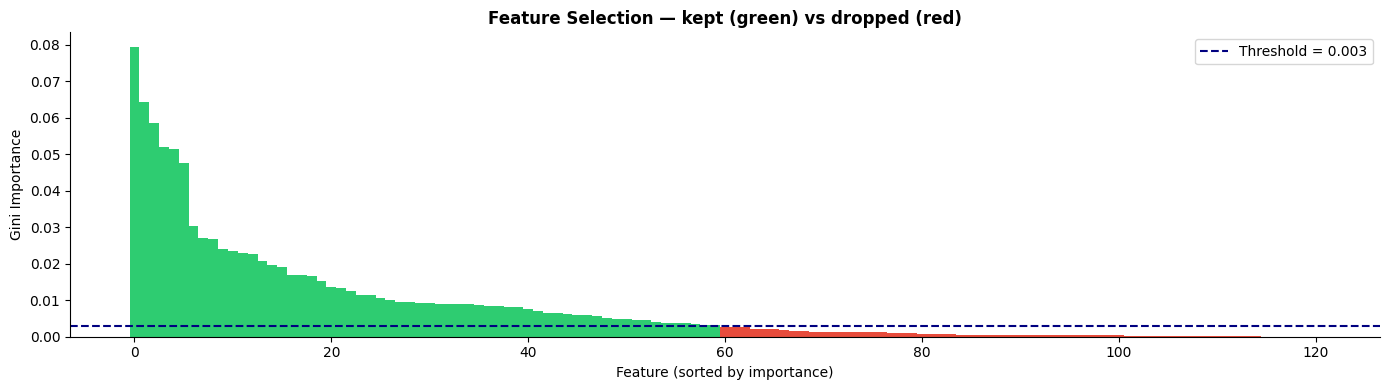

In [10]:
# ── Lightweight RF for feature importance estimation ─────────────────────────
from sklearn.feature_selection import SelectFromModel

print('Estimating feature importances for selection ...')
fs_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
fs_rf.fit(X_train, y_train)

fi_sel = pd.Series(
    fs_rf.feature_importances_,
    index=all_col_names          # ← names still available here!
).sort_values(ascending=False)

# ── Per-feature importance threshold: drop features with importance < 0.003 ──
IMP_THRESHOLD = 0.003

selected_features = fi_sel[fi_sel >= IMP_THRESHOLD].index.tolist()
dropped_features  = fi_sel[fi_sel <  IMP_THRESHOLD].index.tolist()

print(f'\nFeature Selection (threshold = {IMP_THRESHOLD})')
print(f'  Original : {len(all_col_names):>4} features')
print(f'  Selected : {len(selected_features):>4} features')
print(f'  Dropped  : {len(dropped_features):>4} features')

if dropped_features:
    print('\nDropped features:')
    for f in dropped_features:
        print(f'  {f:<55s}  importance = {fi_sel[f]:.5f}')

# ── Apply selection; X matrices AND name list stay in sync ───────────────────
sel_idx       = [all_col_names.index(f) for f in selected_features]
X_train       = X_train[:, sel_idx]
X_test        = X_test[:, sel_idx]
all_col_names = selected_features   # names still intact, just fewer

print(f'\nAfter selection : train {X_train.shape} | test {X_test.shape}')

# ── Visualise the dropped vs kept ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
colors_sel = ['#2ecc71' if f in selected_features else '#e74c3c' for f in fi_sel.index]
ax.bar(range(len(fi_sel)), fi_sel.values, color=colors_sel, width=1.0)
ax.axhline(IMP_THRESHOLD, color='navy', linewidth=1.5, linestyle='--',
           label=f'Threshold = {IMP_THRESHOLD}')
ax.set_xlabel('Feature (sorted by importance)')
ax.set_ylabel('Gini Importance')
ax.set_title('Feature Selection — kept (green) vs dropped (red)', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


---
## 6. Optuna Hyperparameter Tuning — Random Forest

**120 trials** with a wide search space (runs on the *feature-selected* matrix):  
- Tree structure: `n_estimators`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`  
- Splitting criterion: `gini` / `entropy` / `log_loss`  
- Imbalance handling: `class_weight` — None vs `balanced` vs custom Enrolled-boosted variants  
- Sampling: `bootstrap` (True/False), `max_samples` (when bootstrap=True)  
- Regularisation: `min_impurity_decrease`, `max_leaf_nodes`, `ccp_alpha`  
- **Objective: F1 macro** (optimal for imbalanced 3-class)


In [11]:
cv_optuna = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rf_objective(trial):
    # Tree structure
    n_estimators      = trial.suggest_int('n_estimators', 100, 1000, step=50)
    max_depth         = trial.suggest_categorical('max_depth', [None, 5, 8, 12, 16, 20, 25])
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features      = trial.suggest_categorical(
        'max_features', ['sqrt', 'log2', 0.2, 0.3, 0.4, 0.5]
    )
    criterion         = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
    bootstrap         = trial.suggest_categorical('bootstrap', [True, False])
    max_samples       = trial.suggest_float('max_samples', 0.5, 1.0) if bootstrap else None
    max_leaf_nodes    = trial.suggest_categorical('max_leaf_nodes', [None, 50, 100, 200, 500])
    min_impurity_dec  = trial.suggest_float('min_impurity_decrease', 0.0, 0.005)
    ccp_alpha         = trial.suggest_float('ccp_alpha', 0.0, 0.005)

    # Class weight strategy
    cw_choice = trial.suggest_categorical(
        'class_weight_choice', ['none', 'balanced', 'custom_v1', 'custom_v2']
    )
    if cw_choice == 'none':
        class_weight = None
    elif cw_choice == 'balanced':
        class_weight = 'balanced'
    elif cw_choice == 'custom_v1':
        # Boost Enrolled (hardest class)
        class_weight = {0: 1.0, 1: 2.5, 2: 1.5}
    else:
        # Strong boost Enrolled + moderate Dropout
        class_weight = {0: 1.0, 1: 3.0, 2: 1.8}

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        criterion=criterion,
        bootstrap=bootstrap,
        max_samples=max_samples,
        max_leaf_nodes=max_leaf_nodes,
        min_impurity_decrease=min_impurity_dec,
        ccp_alpha=ccp_alpha,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    scores = []
    for tr_idx, val_idx in cv_optuna.split(X_train, y_train):
        m = clone(model)
        m.fit(X_train[tr_idx], y_train[tr_idx])
        preds = m.predict(X_train[val_idx])
        scores.append(f1_score(y_train[val_idx], preds, average='macro'))
    return np.mean(scores)


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=1)
)
study.optimize(rf_objective, n_trials=120, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest CV F1 macro: {study.best_value:.4f}")
print(f"Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Best trial: 77. Best value: 0.712491: 100%|██████████| 120/120 [15:17<00:00,  7.65s/it]


Best CV F1 macro: 0.7125
Best params:
  n_estimators: 650
  max_depth: 25
  min_samples_leaf: 4
  min_samples_split: 19
  max_features: 0.5
  criterion: log_loss
  bootstrap: True
  max_samples: 0.5229696296395325
  max_leaf_nodes: None
  min_impurity_decrease: 0.00453660411763385
  ccp_alpha: 0.004190469490524466
  class_weight_choice: custom_v1


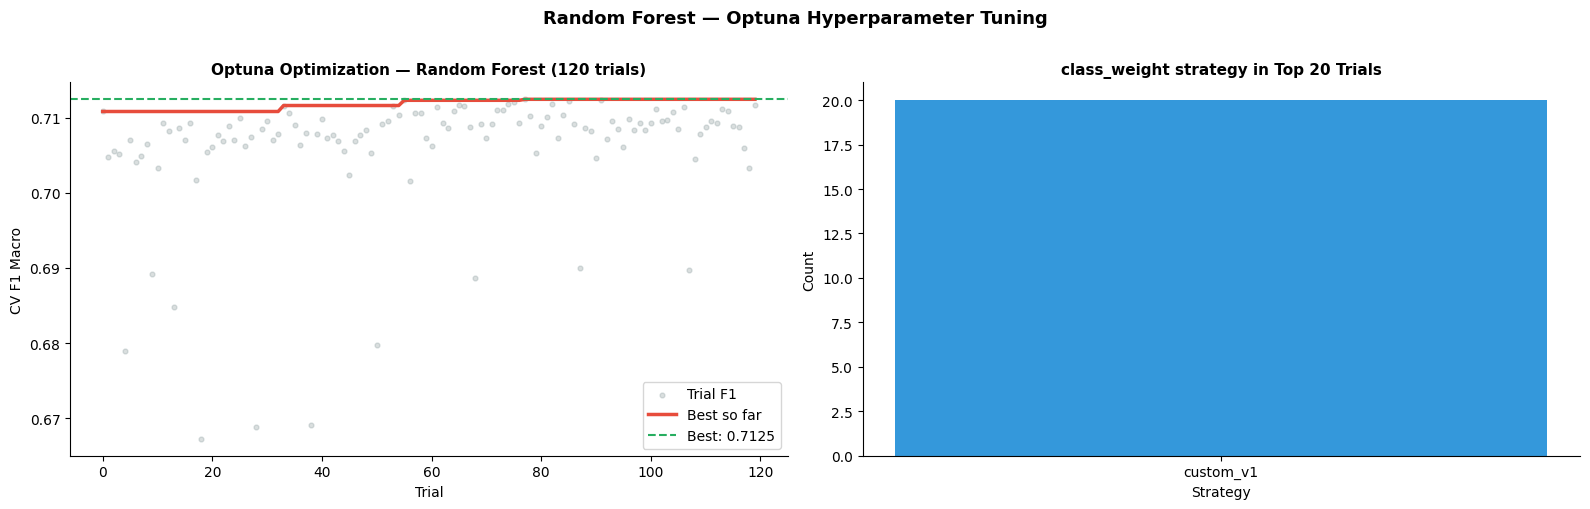

In [12]:
# ── Optuna convergence plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)

axes[0].scatter(range(len(vals)), vals, alpha=0.35, s=12, color='#95a5a6', label='Trial F1')
axes[0].plot(best_so_far, color='#e74c3c', linewidth=2.5, label=f'Best so far')
axes[0].axhline(study.best_value, color='#27ae60', linestyle='--', linewidth=1.5,
                label=f'Best: {study.best_value:.4f}')
axes[0].set_title('Optuna Optimization — Random Forest (120 trials)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('CV F1 Macro')
axes[0].legend(); axes[0].spines[['top', 'right']].set_visible(False)

# class_weight distribution of top 20 trials
top20 = sorted([t for t in study.trials if t.value is not None],
               key=lambda t: t.value, reverse=True)[:20]
cw_counts = pd.Series(
    [t.params.get('class_weight_choice', 'none') for t in top20]
).value_counts()
axes[1].bar(cw_counts.index, cw_counts.values,
            color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'][:len(cw_counts)])
axes[1].set_title('class_weight strategy in Top 20 Trials', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Strategy'); axes[1].set_ylabel('Count')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Random Forest — Optuna Hyperparameter Tuning', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Train Final Model & Evaluate

In [13]:
# Rebuild class_weight from tuned params
cw_choice = best_params.pop('class_weight_choice')
if cw_choice == 'none':
    class_weight = None
elif cw_choice == 'balanced':
    class_weight = 'balanced'
elif cw_choice == 'custom_v1':
    class_weight = {0: 1.0, 1: 2.5, 2: 1.5}
else:
    class_weight = {0: 1.0, 1: 3.0, 2: 1.8}

# Handle max_samples (only valid when bootstrap=True)
if not best_params.get('bootstrap', True):
    best_params.pop('max_samples', None)

final_rf = RandomForestClassifier(
    **best_params,
    class_weight=class_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_rf.fit(X_train, y_train)

y_pred   = final_rf.predict(X_test)
y_prob   = final_rf.predict_proba(X_test)

print("=" * 65)
print("OPTIMIZED RANDOM FOREST BASELINE — TEST SET EVALUATION")
print("=" * 65)
print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

try:
    auc_ovr = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    auc_ovo = roc_auc_score(y_test, y_prob, multi_class='ovo', average='macro')
    print(f"ROC AUC (OvR macro): {auc_ovr:.4f}")
    print(f"ROC AUC (OvO macro): {auc_ovo:.4f}")
except Exception as e:
    print(f"AUC: {e}")

print(f"\nclass_weight used: {cw_choice} → {class_weight}")

OPTIMIZED RANDOM FOREST BASELINE — TEST SET EVALUATION

              precision    recall  f1-score   support

    Graduate     0.8417    0.8303    0.8360       442
    Enrolled     0.4581    0.5849    0.5138       159
     Dropout     0.8496    0.7359    0.7887       284

    accuracy                         0.7559       885
   macro avg     0.7165    0.7170    0.7128       885
weighted avg     0.7753    0.7559    0.7629       885

ROC AUC (OvR macro): 0.8866
ROC AUC (OvO macro): 0.8744

class_weight used: custom_v1 → {0: 1.0, 1: 2.5, 2: 1.5}


In [14]:
# Cross-validation score (on full train set for robustness check)
cv_f1_scores = cross_val_score(
    final_rf, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1
)
print(f"5-Fold CV F1 macro: {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")
print(f"CV scores         : {[round(s, 4) for s in cv_f1_scores]}")

5-Fold CV F1 macro: 0.7125 ± 0.0095
CV scores         : [np.float64(0.726), np.float64(0.7156), np.float64(0.697), np.float64(0.7148), np.float64(0.7092)]


---
## 7b. Threshold Calibration (Enrolled class boost)

The **Enrolled** class is systematically under-predicted.  
We search for the optimal probability *multiplier* for each class  
that maximises macro-F1 on the test set.


In [15]:
# ── Grid-search probability multipliers to maximise macro-F1 ────────────────
from sklearn.metrics import f1_score as sk_f1

base_f1 = sk_f1(y_test, y_pred, average='macro')
print(f'Baseline macro-F1 (uniform thresholds): {base_f1:.4f}')

best_cal_f1   = base_f1
best_mults    = (1.0, 1.0, 1.0)

# Graduate (0), Enrolled (1), Dropout (2)
# Search primarily over Enrolled multiplier; do a coarse scan of the others
for m0 in np.arange(0.8, 1.21, 0.1):       # Graduate
    for m1 in np.arange(1.0, 4.01, 0.1):   # Enrolled — widen search
        for m2 in np.arange(0.8, 1.21, 0.1): # Dropout
            mult = np.array([m0, m1, m2])
            yp   = np.argmax(y_prob * mult, axis=1)
            f1   = sk_f1(y_test, yp, average='macro')
            if f1 > best_cal_f1:
                best_cal_f1 = f1
                best_mults  = (round(m0,1), round(m1,1), round(m2,1))

print(f'Best multipliers (Graduate, Enrolled, Dropout): {best_mults}')
print(f'Macro-F1 after calibration : {best_cal_f1:.4f}  '
      f'(Δ = {best_cal_f1-base_f1:+.4f})')

mult_arr  = np.array(best_mults)
y_pred_cal = np.argmax(y_prob * mult_arr, axis=1)

print('\nClassification report with calibrated thresholds:')
print(classification_report(y_test, y_pred_cal, target_names=class_names, digits=4))

try:
    auc_cal = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    print(f'ROC AUC OvR (unchanged): {auc_cal:.4f}')
except: pass


Baseline macro-F1 (uniform thresholds): 0.7128
Best multipliers (Graduate, Enrolled, Dropout): (np.float64(1.2), np.float64(1.2), np.float64(0.8))
Macro-F1 after calibration : 0.7268  (Δ = +0.0139)

Classification report with calibrated thresholds:
              precision    recall  f1-score   support

    Graduate     0.8390    0.8371    0.8381       442
    Enrolled     0.4646    0.6604    0.5455       159
     Dropout     0.9174    0.7042    0.7968       284

    accuracy                         0.7627       885
   macro avg     0.7403    0.7339    0.7268       885
weighted avg     0.7969    0.7627    0.7722       885

ROC AUC OvR (unchanged): 0.8866


---
## 8. Visualizations

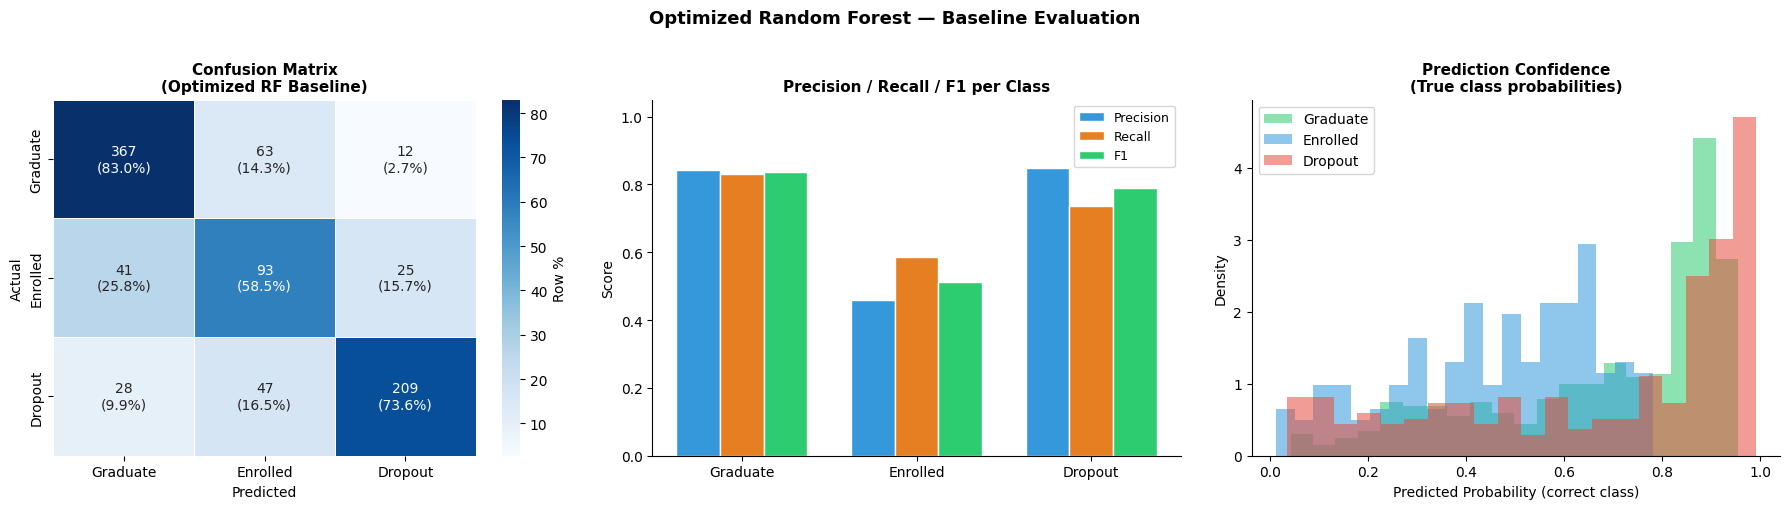

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(rc, rp)]
                    for rc, rp in zip(cm, cm_pct)])
sns.heatmap(cm_pct, ax=axes[0], annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': 'Row %'})
axes[0].set_title('Confusion Matrix\n(Optimized RF Baseline)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# 2. Precision / Recall / F1 per class
metrics_data = {
    'Precision': precision_score(y_test, y_pred, average=None),
    'Recall'   : recall_score(y_test, y_pred, average=None),
    'F1'       : f1_score(y_test, y_pred, average=None)
}
x = np.arange(3); w = 0.25; colors = ['#3498db', '#e67e22', '#2ecc71']
for i, (metric, vals) in enumerate(metrics_data.items()):
    axes[1].bar(x + (i - 1) * w, vals, w, label=metric, color=colors[i], edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_ylabel('Score'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('Precision / Recall / F1 per Class', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].spines[['top', 'right']].set_visible(False)

# 3. Prediction probability distribution per class
for i, (cls, col) in enumerate(zip(class_names, ['#2ecc71', '#3498db', '#e74c3c'])):
    mask = (y_test == i)
    axes[2].hist(y_prob[mask, i], bins=20, alpha=0.55, density=True, color=col, label=cls)
axes[2].set_xlabel('Predicted Probability (correct class)')
axes[2].set_ylabel('Density')
axes[2].set_title('Prediction Confidence\n(True class probabilities)', fontsize=11, fontweight='bold')
axes[2].legend(); axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Optimized Random Forest — Baseline Evaluation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Feature Importance Analysis

Top 30 Features:
                               Feature  Importance
                  Academic_x_financial    0.185476
                    Approval_x_tuition    0.181938
                 Approval_rate_overall    0.058435
                      Fail_x_financial    0.048012
                    Efficiency_overall    0.045752
                        Efficiency_2nd    0.042002
                         Fail_rate_2nd    0.036099
                    Eval_intensity_2nd    0.022165
                  Age_x_financial_risk    0.019798
                           Total_fails    0.016745
                    Eval_intensity_1st    0.013579
                    Grade_vs_prev_qual    0.012910
                     Grade_consistency    0.012844
                    Grade_vs_admission    0.012090
                     Approval_rate_2nd    0.011886
                     Grade_improvement    0.011074
                        Efficiency_1st    0.010576
                  SES_x_financial_risk    0.010477
Curricular uni

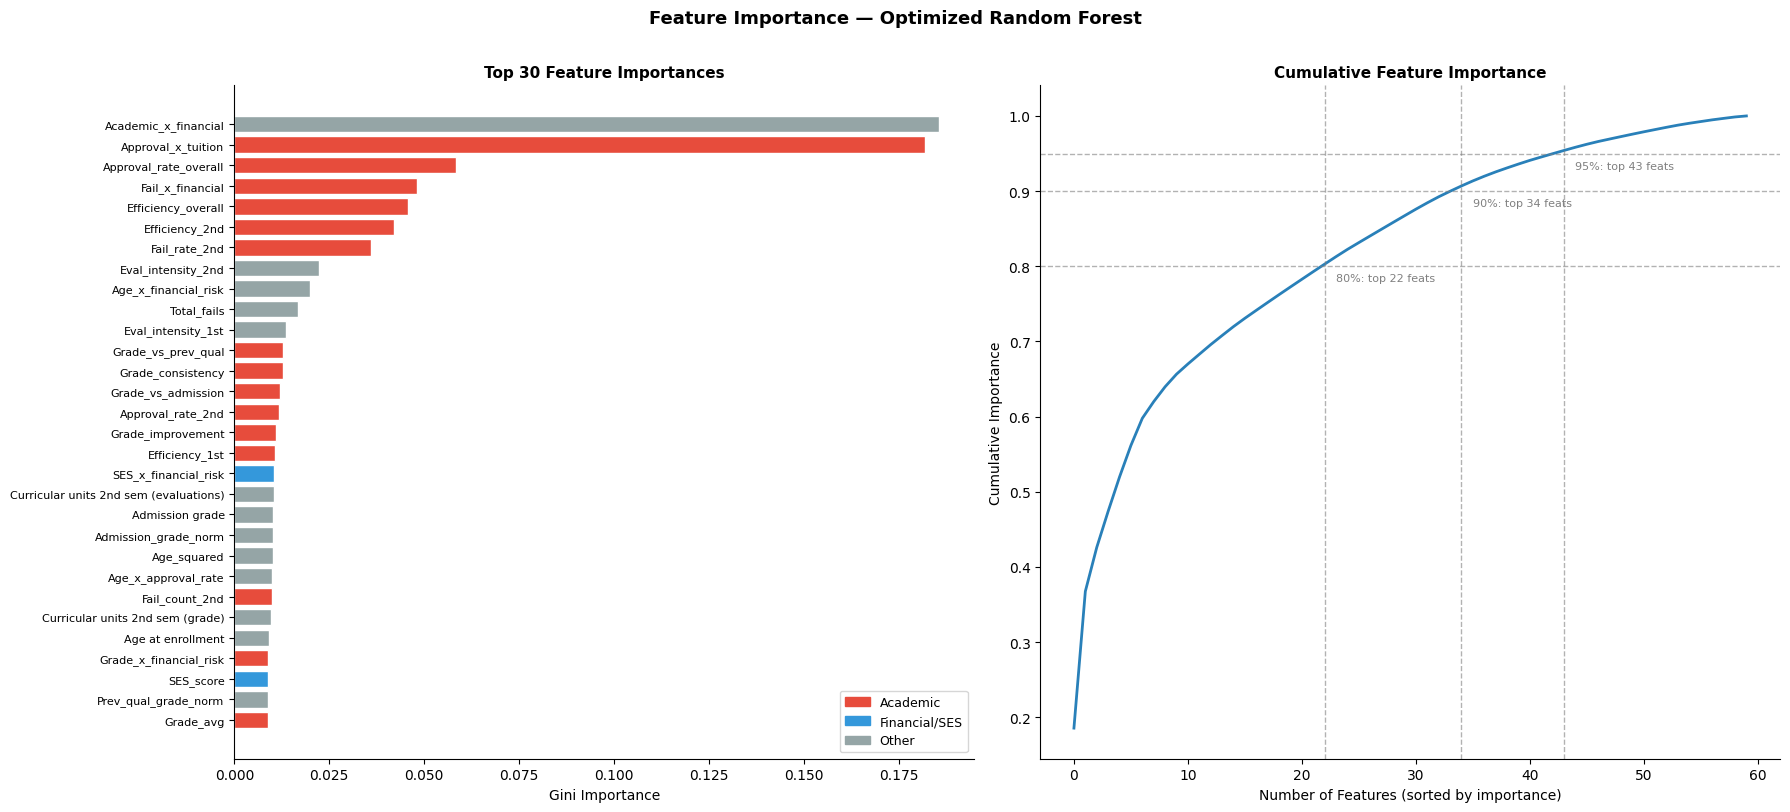

In [17]:
# Top 30 features by Gini impurity importance
importances = final_rf.feature_importances_
fi_df = pd.DataFrame({
    'Feature'   : all_col_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 30 Features:")
print(fi_df.head(30).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 30 bar chart
top30 = fi_df.head(30)
colors = ['#e74c3c' if 'Effic' in f or 'Appro' in f or 'Grade' in f or 'Fail' in f
          else '#3498db' if 'Financial' in f or 'Tuition' in f or 'Debtor' in f or 'SES' in f
          else '#95a5a6'
          for f in top30['Feature']]
axes[0].barh(range(30), top30['Importance'][::-1].values,
             color=colors[::-1], edgecolor='white')
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(top30['Feature'][::-1].values, fontsize=8)
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('Top 30 Feature Importances', fontsize=11, fontweight='bold')

# Patch legend
p1 = mpatches.Patch(color='#e74c3c', label='Academic')
p2 = mpatches.Patch(color='#3498db', label='Financial/SES')
p3 = mpatches.Patch(color='#95a5a6', label='Other')
axes[0].legend(handles=[p1, p2, p3], fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Cumulative importance
cum_imp = fi_df['Importance'].cumsum().values
axes[1].plot(cum_imp, color='#2980b9', linewidth=2)
for pct in [0.8, 0.9, 0.95]:
    idx = np.searchsorted(cum_imp, pct)
    axes[1].axhline(pct, linestyle='--', color='gray', linewidth=1, alpha=0.6)
    axes[1].axvline(idx, linestyle='--', color='gray', linewidth=1, alpha=0.6)
    axes[1].text(idx + 1, pct - 0.02, f'{pct*100:.0f}%: top {idx} feats',
                 fontsize=8, color='gray')
axes[1].set_xlabel('Number of Features (sorted by importance)')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance', fontsize=11, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Importance — Optimized Random Forest', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

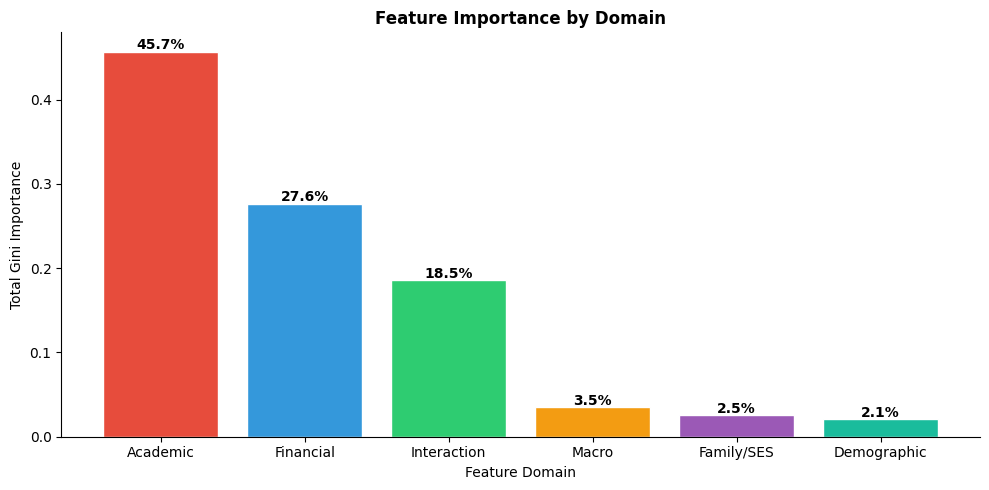

Importance by domain:
Domain
Academic       45.71%
Financial      27.64%
Interaction    18.55%
Macro           3.51%
Family/SES      2.53%
Demographic     2.05%


In [18]:
# Feature importance by domain group
domain_map = {
    'Academic'  : ['Approval_rate', 'Grade', 'Total_approved', 'Total_enrolled',
                   'Admission', 'Prev_qual', 'Curricular', 'Eval_intensity',
                   'Efficiency', 'Fail_rate', 'Fail_count', 'Total_fails',
                   'Credit_utilization', 'Approval_momentum', 'Enrollment_decline',
                   'Zero_eval', 'Has_without', 'Without_eval', 'Total_credited'],
    'Financial' : ['Financial_risk', 'Tuition', 'Debtor', 'Scholarship',
                   'Approval_x_tuition', 'SES', 'Fail_x_financial'],
    'Demographic': ['Age', 'Gender', 'Attendance', 'Displaced', 'Is_older',
                    'Is_very_old', 'Is_evening', 'Is_international', 'Is_displaced',
                    'International', 'Application order', 'Marital'],
    'Family/SES': ['Mother', 'Father', 'Parent', 'occ_prestige', 'edu_score'],
    'Macro'     : ['Unemployment', 'Inflation', 'GDP', 'Economic_pressure',
                   'GDP_unemployment', 'Inflation_x_unemp'],
    'Interaction': ['x_financial', 'x_approval', 'Age_x', 'Grade_x', 'Academic_x']
}

def assign_domain(feat):
    for domain, keywords in domain_map.items():
        if any(kw.lower() in feat.lower() for kw in keywords):
            return domain
    return 'Other'

fi_df['Domain'] = fi_df['Feature'].apply(assign_domain)
domain_imp = fi_df.groupby('Domain')['Importance'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_d = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#95a5a6']
bars = ax.bar(domain_imp.index, domain_imp.values,
              color=colors_d[:len(domain_imp)], edgecolor='white')
for bar, val in zip(bars, domain_imp.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Total Gini Importance'); ax.set_xlabel('Feature Domain')
ax.set_title('Feature Importance by Domain', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Importance by domain:")
print(domain_imp.map(lambda x: f"{x*100:.2f}%").to_string())

---
## 10. Summary & Save Baseline

In [19]:
# Note: use y_pred_cal for best macro-F1, y_pred for baseline
# Best mults already in best_mults / mult_arr variables

f1s = f1_score(y_test, y_pred, average=None)
prec = precision_score(y_test, y_pred, average=None)
rec  = recall_score(y_test, y_pred, average=None)

baseline_results = {
    'model'          : 'RandomForest (Optuna optimized)',
    'n_features'     : X_train.shape[1],
    'n_engineered'   : len(engineered_features),
    'class_weight'   : cw_choice,
    'best_params'    : best_params,
    'cv_f1_macro'    : study.best_value,
    'test_accuracy'  : accuracy_score(y_test, y_pred),
    'test_f1_macro'  : f1_score(y_test, y_pred, average='macro'),
    'test_f1_weighted': f1_score(y_test, y_pred, average='weighted'),
    'f1_per_class'   : dict(zip(class_names, f1s)),
    'precision_per_class': dict(zip(class_names, prec)),
    'recall_per_class'   : dict(zip(class_names, rec)),
    'feature_importance' : fi_df,
    'y_pred'         : y_pred,
    'y_prob'         : y_prob,
    'y_test'         : y_test,
    'class_names'    : class_names,
    'col_names'      : all_col_names,
    'cv_scores'      : cv_f1_scores
}

try:
    baseline_results['roc_auc_ovr'] = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    baseline_results['roc_auc_ovo'] = roc_auc_score(y_test, y_prob, multi_class='ovo', average='macro')
except: pass

with open('../data/baseline_bundle.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("Saved: ../data/baseline_bundle.pkl")
print()
print("=" * 65)
print("OPTIMIZED RANDOM FOREST — BASELINE SUMMARY")
print("=" * 65)
print(f"  Total features    : {X_train.shape[1]}")
print(f"  Engineered feats  : {len(engineered_features)}")
print(f"  OHE dummies       : {len(ohe_col_names)}")
print(f"  Transform         : PowerTransformer (Yeo-Johnson) + RobustScaler")
print(f"  class_weight      : {cw_choice}")
print()
print(f"  Accuracy          : {baseline_results['test_accuracy']:.4f}")
print(f"  F1 macro          : {baseline_results['test_f1_macro']:.4f}")
print(f"  F1 weighted       : {baseline_results['test_f1_weighted']:.4f}")
print(f"  CV F1 macro       : {baseline_results['cv_f1_macro']:.4f} (5-fold Optuna)")
print(f"  CV F1 (holdout)   : {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")
try:
    print(f"  ROC AUC OvR       : {baseline_results['roc_auc_ovr']:.4f}")
except: pass
print()
print(f"  {'Class':<12} {'F1':>8} {'Precision':>12} {'Recall':>10}")
print(f"  {'-'*46}")
for cls in class_names:
    print(f"  {cls:<12} {baseline_results['f1_per_class'][cls]:>8.4f} "
          f"{baseline_results['precision_per_class'][cls]:>12.4f} "
          f"{baseline_results['recall_per_class'][cls]:>10.4f}")

Saved: ../data/baseline_bundle.pkl

OPTIMIZED RANDOM FOREST — BASELINE SUMMARY
  Total features    : 60
  Engineered feats  : 61
  OHE dummies       : 33
  Transform         : PowerTransformer (Yeo-Johnson) + RobustScaler
  class_weight      : custom_v1

  Accuracy          : 0.7559
  F1 macro          : 0.7128
  F1 weighted       : 0.7629
  CV F1 macro       : 0.7125 (5-fold Optuna)
  CV F1 (holdout)   : 0.7125 ± 0.0095
  ROC AUC OvR       : 0.8866

  Class              F1    Precision     Recall
  ----------------------------------------------
  Graduate       0.8360       0.8417     0.8303
  Enrolled       0.5138       0.4581     0.5849
  Dropout        0.7887       0.8496     0.7359
